### Filter metadata and files based in the counts of run per BioProject.

#### Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option("display.max_rows", None)

#### Import data

In [2]:
sugarcane_rna_df = pd.read_csv(
    "../raw/sugarcane_with_pmid_with_articles_with_dois.csv", header=0, low_memory=False
)

In [3]:
# Count the number of runs per BioProject
sugarcane_rna_counts = sugarcane_rna_df["BioProject"].value_counts()

#### Check the runs distribution

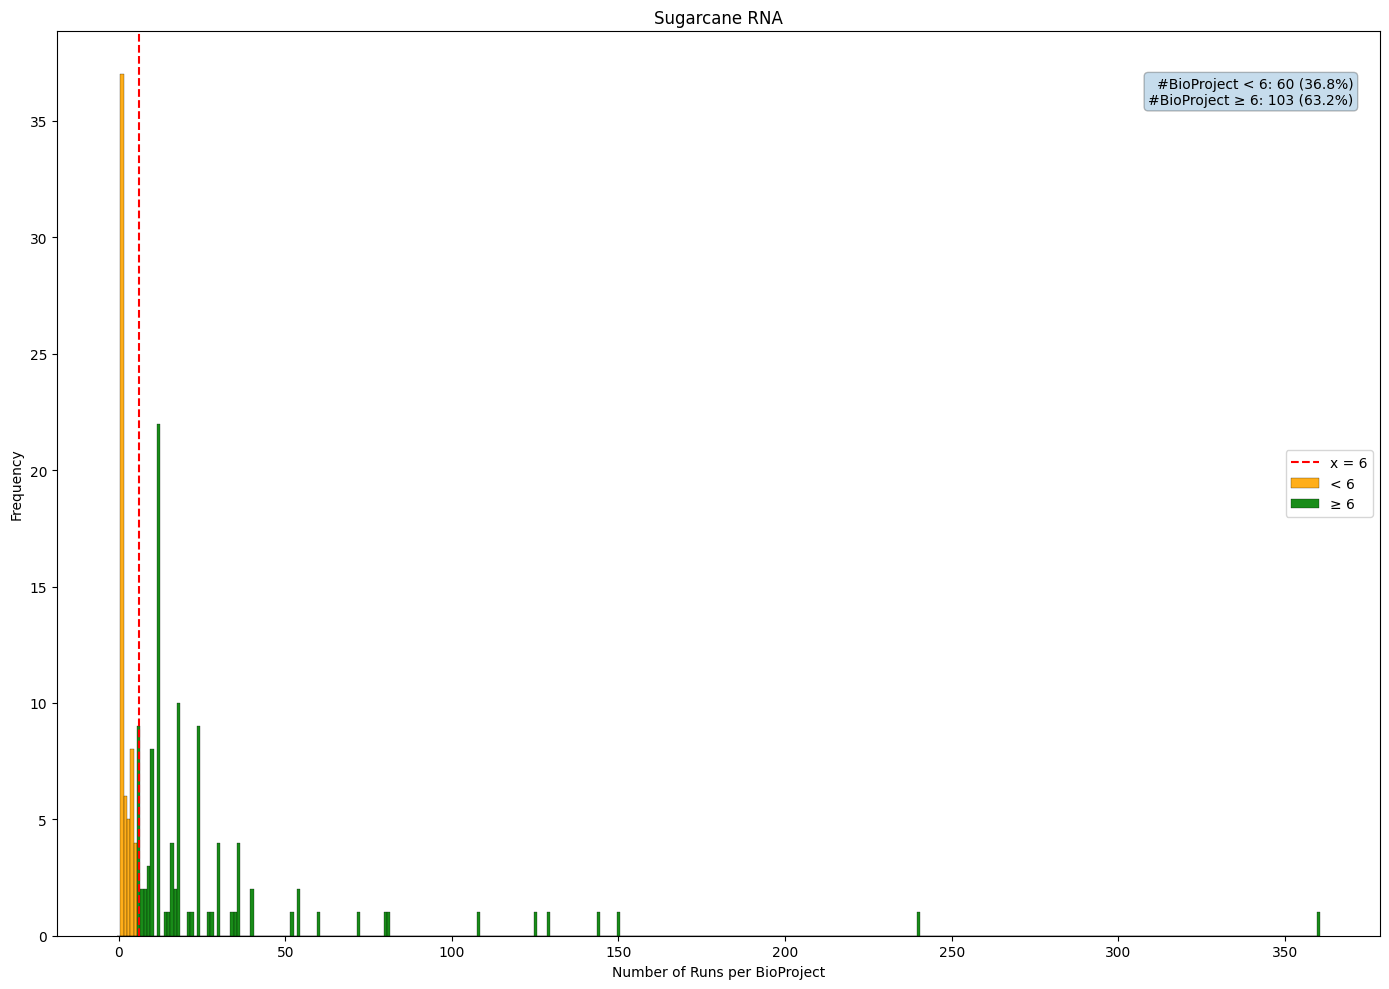

In [9]:
# Threshold for categorization
threshold = 6

datasets = [
    (sugarcane_rna_counts, "Sugarcane RNA"),
]

fig, axes = plt.subplots(1, 1, figsize=(14, 10))
axes = np.array([axes])  # Ensure axes is iterable

for ax, (counts, label) in zip(axes, datasets):
    counts = np.asarray(counts)
    if counts.size == 0:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center")
        ax.set_title(label)
        continue

    # Use integer-centered bins (good for "counts" data)
    xmin = 0
    xmax = counts.max()
    bins = np.arange(xmin - 0.5, xmax + 1.5, 1)  # centers bins on integers

    # Split data into <=threshold and >threshold so we can color them separately
    mask_le_threshold = counts < threshold
    mask_gt_threshold = counts >= threshold

    # Plot the two parts (they don't double-count because masks partition the data)
    sns.histplot(
        counts[mask_le_threshold],
        bins=bins,
        ax=ax,
        kde=False,
        label=f"< {threshold}",
        alpha=0.9,
        color="orange",
    )
    if mask_gt_threshold.sum() > 0:
        sns.histplot(
            counts[mask_gt_threshold],
            bins=bins,
            ax=ax,
            kde=False,
            label=f"≥ {threshold}",
            alpha=0.9,
            color="green",
        )

    # mark x=threshold and set log scale for y
    ax.axvline(
        threshold, color="red", linestyle="--", linewidth=1.5, label=f"x = {threshold}"
    )
    # ax.set_yscale('log')

    # labels & title
    ax.set_xlabel("Number of Runs per BioProject")
    # ax.set_ylabel('Frequency (log scale)')
    ax.set_ylabel("Frequency")
    ax.set_title(label)

    # compute percentile: percent of values <= threshold
    # Count how many values are >= threshold and present in the plot
    count_le_threshold = np.sum(counts < threshold)
    pct_le_threshold = (count_le_threshold / counts.size) * 100
    count_ge_threshold = np.sum(counts >= threshold)
    pct_ge_threshold = (count_ge_threshold / counts.size) * 100

    ax.text(
        0.98,
        0.95,
        f"#BioProject < {threshold}: {count_le_threshold} ({pct_le_threshold:.1f}%)\n#BioProject ≥ {threshold}: {count_ge_threshold} ({pct_ge_threshold:.1f}%)",
        transform=ax.transAxes,
        ha="right",
        va="top",
        bbox=dict(boxstyle="round", alpha=0.25),
    )

    ax.legend()

# If you supplied fewer than 4 datasets, turn off remaining axes
if len(datasets) < len(axes):
    for ax in axes[len(datasets) :]:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# Filter the dataframes with BioProjects with at least 6 runs
def filter_bioprojects_with_min_runs(
    df: pd.DataFrame, bioproject_col: str = "BioProject", min_runs: int = 6
) -> pd.DataFrame:
    """
    Keep only rows where the BioProject has at least `min_runs` entries.
    Args:
        df: Input DataFrame containing a column with BioProject IDs.
        bioproject_col: Name of the column in `df` that contains BioProject IDs.
        min_runs: Minimum number of runs required for a BioProject to be kept.
    Returns:
        A filtered DataFrame containing only rows from BioProjects with at least `min_runs` entries
    """
    counts = df[bioproject_col].value_counts()
    valid_projects = counts[counts >= min_runs].index
    filtered_df = df[df[bioproject_col].isin(valid_projects)]
    return filtered_df

In [11]:
# Apply the filter to the sugarcane RNA dataset
sugarcane_rna_filtered = filter_bioprojects_with_min_runs(sugarcane_rna_df)

In [12]:
def validate_filtering(
    df: pd.DataFrame, fdf: pd.DataFrame, name: str, min_runs: int = 6
):
    """
    Validate that filtering worked correctly by showing BioProject size distributions.
    Args:
        df: Original DataFrame before filtering.
        fdf: Filtered DataFrame after applying the filter.
        name: Name of the dataset (for reporting purposes).
        min_runs: The minimum number of runs that was used as the filtering threshold.
    """
    print(f"\n{'=' * 60}")
    print(f"{name}")
    print(f"{'=' * 60}")

    # Count runs per BioProject in original data
    original_counts = df["BioProject"].value_counts()

    # Separate into should-be-kept vs should-be-removed
    should_keep = original_counts[original_counts >= min_runs]
    should_remove = original_counts[original_counts < min_runs]

    print(f"\nORIGINAL DATA:")
    print(f"  Total BioProjects: {len(original_counts)}")
    print(f"  BioProjects with >= {min_runs} runs: {len(should_keep)} (should KEEP)")
    print(f"  BioProjects with < {min_runs} runs: {len(should_remove)} (should REMOVE)")
    print(f"  Total rows: {len(df):,}")
    print(f"  Rows in projects >= {min_runs}: {should_keep.sum():,}")
    print(f"  Rows in projects < {min_runs}: {should_remove.sum():,}")

    # Count runs per BioProject in filtered data
    filtered_counts = fdf["BioProject"].value_counts()

    print(f"\nFILTERED DATA:")
    print(f"  Total BioProjects: {len(filtered_counts)}")
    print(f"  Total rows: {len(fdf):,}")
    print(f"  Min runs per project: {filtered_counts.min()}")
    print(f"  Max runs per project: {filtered_counts.max()}")

    # VALIDATION CHECKS
    print(f"\nVALIDATION:")

    # Check 1: All filtered projects should have >= min_runs
    invalid_projects = filtered_counts[filtered_counts < min_runs]
    if len(invalid_projects) > 0:
        print(
            f"  ERROR: {len(invalid_projects)} projects with < {min_runs} runs found!"
        )
        print(f"     {invalid_projects}")
    else:
        print(f"  All filtered projects have >= {min_runs} runs")

    # Check 2: Row counts should match
    expected_rows = should_keep.sum()
    actual_rows = len(fdf)
    if expected_rows == actual_rows:
        print(f"  Row count matches: {actual_rows:,} rows")
    else:
        print(f"  ERROR: Expected {expected_rows:,} rows, got {actual_rows:,}")

    # Check 3: Project counts should match
    expected_projects = len(should_keep)
    actual_projects = len(filtered_counts)
    if expected_projects == actual_projects:
        print(f"  Project count matches: {actual_projects} projects")
    else:
        print(f"  ERROR: Expected {expected_projects} projects, got {actual_projects}")

    # Show distribution
    print(f"\nDISTRIBUTION OF RUNS PER PROJECT (original):")
    print(
        f"  < {min_runs} runs: {len(should_remove)} projects ({should_remove.sum():,} rows) - REMOVED"
    )
    print(
        f"  >= {min_runs} runs: {len(should_keep)} projects ({should_keep.sum():,} rows) - KEPT"
    )

In [13]:
# Run validation for all datasets
for name, df, fdf in [
    ("Sugarcane RNA", sugarcane_rna_df, sugarcane_rna_filtered),
]:
    validate_filtering(df, fdf, name, min_runs=6)


Sugarcane RNA

ORIGINAL DATA:
  Total BioProjects: 163
  BioProjects with >= 6 runs: 103 (should KEEP)
  BioProjects with < 6 runs: 60 (should REMOVE)
  Total rows: 3,314
  Rows in projects >= 6: 3,198
  Rows in projects < 6: 116

FILTERED DATA:
  Total BioProjects: 103
  Total rows: 3,198
  Min runs per project: 6
  Max runs per project: 360

VALIDATION:
  All filtered projects have >= 6 runs
  Row count matches: 3,198 rows
  Project count matches: 103 projects

DISTRIBUTION OF RUNS PER PROJECT (original):
  < 6 runs: 60 projects (116 rows) - REMOVED
  >= 6 runs: 103 projects (3,198 rows) - KEPT


In [14]:
# Include a new column with the run counts per BioProject in the filtered dataframes
def add_run_count_column(
    df: pd.DataFrame, bioproject_col: str = "BioProject", count_col: str = "RunCount"
) -> pd.DataFrame:
    """
    Add a new column to the dataframe with the count of runs per BioProject.
    Args:
        df: Input DataFrame containing a column with BioProject IDs.
        bioproject_col: Name of the column in `df` that contains BioProject IDs.
        count_col: Name of the new column to be added with the run counts.
    Returns:
        A DataFrame with the new column containing the count of runs per BioProject.
    """
    df = df.copy()
    counts = df[bioproject_col].value_counts()
    df[count_col] = df[bioproject_col].map(counts)
    return df

In [15]:
# Add the run count column to the filtered sugarcane RNA dataframe
sugarcane_rna_filtered = add_run_count_column(sugarcane_rna_filtered)

In [ ]:
# Save the filtered dataframes to new CSV files
sugarcane_rna_filtered.to_csv("../raw/sugarcane_rna_filtered.csv", index=False)